In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
from opensim_pendulum import OpenSimPendulum

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import SysSimX

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
from MyModels.MasterPendulum.pendulum_ode import PendulumODE, ramp_torque, constant_torque
from MyModels.FEM.fem_pendulum import FEMPendulum

In [2]:
master = FEMPendulum('Master')
master._use_gravity = True
master._with_contact = False
master.initialize(0.0)

model = OpenSimPendulum()
model._use_gravity = master._use_gravity
model._with_contact = master._with_contact

total_inertia = master.inertia
mass = master.mass
length = master._equivalent_length
inertia = total_inertia - mass * (length ** 2)

model.parameters['Model']['inertia'] = inertia
model.parameters['Model']['mass'] = mass
model.parameters['Model']['length'] = length

model.parameters['InitialConditions']['q0'] = 0
model.parameters['InitialConditions']['omega0'] = 0
model.parameters['InitialConditions']['torque0'] = 40

model.initialize(0.0)

In [3]:
# viz = osim.VisualizerUtilities()
# viz.showModel(model.model)

In [4]:
t_end = 1
dt = 0.01
t = 0.0

torque_amp = 40
#torque_func: callable = ramp_torque(t_end, torque_amp)
torque_func: callable = constant_torque(torque_amp)

# Analytical Solution using ODE Pendulum
pendulum_ode = PendulumODE(mass=master.mass,
                           length=master._equivalent_length,
                           inertia=master.inertia,
                           g= 9.81 if master._use_gravity else 0.0)


t_an_vals, q_an_vals, omega_an_vals, alpha_an_vals = pendulum_ode.solve(t_span=(0.0, t_end),
                                                    y0=[0, 0.0],
                                                    torque_func=torque_func,
                                                    dt=dt)

In [5]:
while t < t_end:
    # 1) Compute input torque
    torque = torque_func(t)
    
    # 2) Perform simulation step
    model.set_inputs({'torque': torque}, t=t)

    # 3) Integrate one time step
    model.do_step(t, dt)

    # 4) Advance time
    t += dt

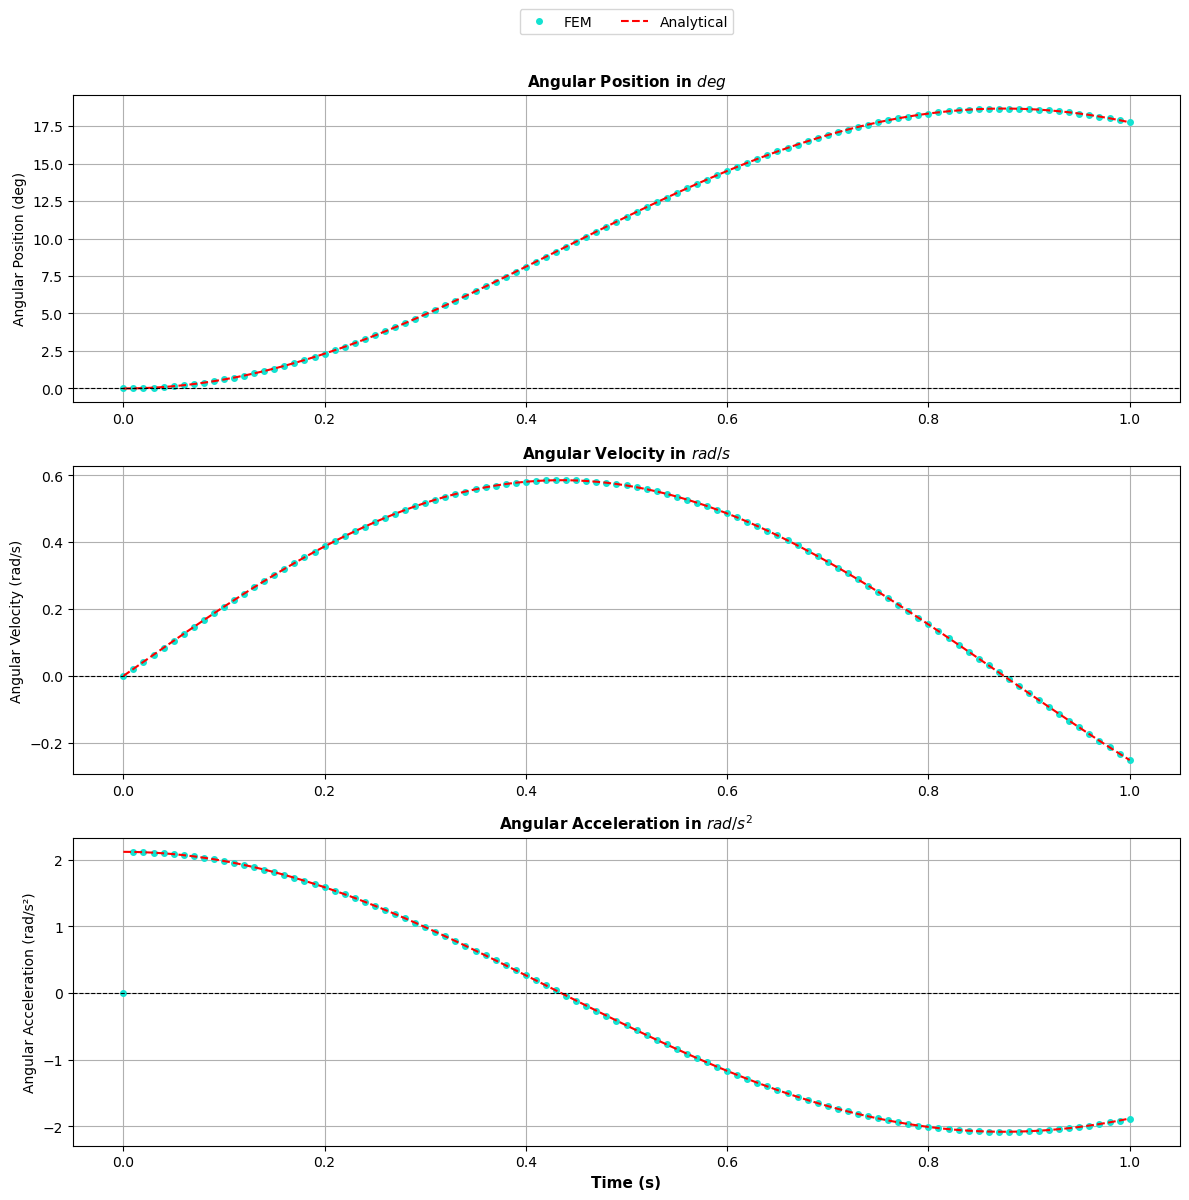

In [6]:
results = model.get_history()

t_vals = results['q']['time']
q_fem_vals = results['q']['values']
omega_fem_vals = results['omega']['values']
alpha_fem_vals = results['alpha']['values']

marker_size = 4
fem_style = {'color': "#12e2d1", 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size, 'linewidth': 3.5}  
opensim_style = {'color': "#f8c20f", 'linestyle': 'None', 'marker': 's', 'markersize': marker_size, 'linewidth': 3.5} 
eqb_style = {'color': "#1d8d43", 'linestyle': 'None', 'marker': '^', 'markersize': marker_size, 'linewidth': 3.5}
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

plt.figure(figsize=(12, 12))

plt.subplot(3,1,1).set_title("Angular Position in $deg$", **fontdict)
plt.plot(t_vals, np.rad2deg(q_fem_vals), label="FEM", **fem_style)
plt.plot(t_an_vals, np.rad2deg(q_an_vals), label="Analytical", color='red', linestyle='--')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Position (deg)")
plt.grid(which='both')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)

plt.subplot(3,1,2).set_title("Angular Velocity in $rad/s$", **fontdict)
plt.plot(t_vals, omega_fem_vals, label="FEM", **fem_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.plot(t_an_vals, omega_an_vals, label="Analytical", color='red', linestyle='--')
plt.ylabel("Angular Velocity (rad/s)")
plt.grid(which='both')

plt.subplot(3,1,3).set_title("Angular Acceleration in $rad/s^2$", **fontdict)
plt.plot(t_vals, alpha_fem_vals, label="FEM", **fem_style)
plt.plot(t_an_vals, alpha_an_vals, label="Analytical", color='red', linestyle='--')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Acceleration (rad/s²)")
plt.grid(which='both')

plt.xlabel("Time (s)", **fontdict)
plt.tight_layout()
#plt.savefig("../figures/StateSynchronization_driven.svg")
plt.show()